In [5]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import pygeovision as pgv

# Initialize client
client = pgv.PyGeoVision()
print(f"PyGeoVision version: {pgv.__version__}")

23:07:13 INFO [      engine] PyGeoFetch ready


2026-07-29 23:07:13,448 [INFO] pygeofetch.core.engine: PyGeoFetch ready


23:07:13 INFO [      engine] PyGeoFetch ready


2026-07-29 23:07:13,449 [INFO] pygeofetch.core.engine: PyGeoFetch ready
2026-07-29 23:07:13,450 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v1.0 Python API active — using native search/download
2026-07-29 23:07:13,450 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v2.0 processing engine detected — using native preprocessing


PyGeoVision version: 2.1.6


In [6]:

# ============================================================
# 1. Define AOI (London area for canopy height)
# ============================================================
BBOX = (-0.15, 51.47, -0.1, 51.52)  # London, UK
DATE_RANGE = ('2024-06-01', '2024-08-31')
PROVIDERS = ['planetary_computer',]

DATA_DIR = pathlib.Path('./results/canopy_height')
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
# ============================================================
# 2. Search for Sentinel-2 data (for canopy height estimation)
# ============================================================
print("\n" + "="*60)
print("SEARCHING FOR SENTINEL-2 DATA")
print("="*60)

results = client.search(
    bbox=BBOX,
    date_range=DATE_RANGE,
    providers=PROVIDERS,
    cloud_cover_max=10,
)
print(f"Found {len(results)} scenes")
for r in results[:5]:
    print(f"  {r.provider:<22} {r.datetime[:10]}  cloud={r.cloud_cover:.1f}%  {r.id[:40]}")



SEARCHING FOR SENTINEL-2 DATA
Found 8 scenes
  planetary_computer     2024-08-23  cloud=6.3%  S2A_MSIL2A_20240823T110621_R137_T30UXC_2
  planetary_computer     2024-07-31  cloud=0.2%  S2A_MSIL2A_20240731T105621_R094_T30UXC_2
  planetary_computer     2024-07-30  cloud=6.9%  LC09_L2SP_202024_20240730_02_T1
  planetary_computer     2024-07-29  cloud=2.7%  S2B_MSIL2A_20240729T110619_R137_T30UYC_2
  planetary_computer     2024-07-29  cloud=7.2%  S2B_MSIL2A_20240729T110619_R137_T30UXC_2


In [8]:
# ============================================================
# 3. Download Sentinel-2 (for canopy height estimation)
# ============================================================
print("\n" + "="*60)
print("DOWNLOADING SENTINEL-2 DATA")
print("="*60)

BANDS = ['B02', 'B03', 'B04', 'B08', 'B8A', 'B11', 'B12']

downloads = client.download(
    results[:1],  # Download first scene
    output_dir=str(DATA_DIR),
    bands=BANDS,
    post_process=['reproject:EPSG:32630', 'cog'],
)

scene_path = downloads[0].path if downloads and downloads[0].success else None
scl_cands = list(DATA_DIR.rglob('*SCL*.tif')) + list(DATA_DIR.rglob('*scl*.tif'))
scl_path = str(scl_cands[0]) if scl_cands else None

if scene_path:
    d = downloads[0]
    print(f"Downloaded   : {scene_path}")
    print(f"Size         : {d.bytes_downloaded/1024/1024:.1f} MB")
    print(f"SCL mask     : {scl_path}")
else:
    print("Download failed or scene unavailable — check provider availability")

2026-07-29 23:07:13,493 [INFO] pygeovision.data.fetch: Downloading 1 pystac-fallback item(s) directly (bypassing PyGeoFetch engine).



DOWNLOADING SENTINEL-2 DATA


2026-07-29 23:07:14,332 [INFO] pygeovision.data.fetch:   [direct] S2A_MSIL2A_20240823T110621_R137_T30UXC_20240823T172700  B02 → S2A_MSIL2A_20240823T110621_R137_T30UXC_20240823T172700_B02.tif


KeyboardInterrupt: 

In [ ]:
# ============================================================
# 4. Search for LiDAR/Point Cloud Data from OpenTopography
# ============================================================
print("\n" + "="*60)
print("SEARCHING FOR LIDAR POINT CLOUD DATA (OpenTopography)")
print("="*60)

# Search for LiDAR data in the same area
# Note: OpenTopography uses 'collections' parameter with dataset names
# Search for available LiDAR collections
lidar_results = client.search(
    providers=["opentopography"],  # Must be a list
    bbox=BBOX,
    collections=[],  # Empty list to find all available collections
    date_range=("2020-01-01", "2025-01-01"),
    max_results=50
)

print(f"Found {len(lidar_results)} LiDAR datasets")
for r in lidar_results[:5]:
    print(f"  {r.id[:50]}")
    print(f"    Provider: {r.provider}")
    print(f"    Collection: {r.collection}")
    print(f"    Date: {r.datetime}")
    # print(f"    Title: {r.title[:50] if r.title else 'N/A'}")
    # print(f"    Metadata: {list(r.metadata.keys()) if r.metadata else 'None'}")
    print("---")



SEARCHING FOR LIDAR POINT CLOUD DATA (OpenTopography)
Found 7 LiDAR datasets
  opentopo_SRTMGL3_-0.15_51.47
    Provider: opentopography
    Collection: 
    Date: 
---
  opentopo_SRTMGL1_-0.15_51.47
    Provider: opentopography
    Collection: 
    Date: 
---
  opentopo_COP30_-0.15_51.47
    Provider: opentopography
    Collection: 
    Date: 
---
  opentopo_COP90_-0.15_51.47
    Provider: opentopography
    Collection: 
    Date: 
---
  opentopo_NASADEM_-0.15_51.47
    Provider: opentopography
    Collection: 
    Date: 
---


In [ ]:
# ============================================================
# 4b. Search for Specific OpenTopography LiDAR Collections
# ============================================================
print("\n" + "="*60)
print("SEARCHING FOR SPECIFIC LIDAR COLLECTIONS")
print("="*60)

# If you know specific collection names, you can search directly
# Common OpenTopography collections include:
# - USGS_LPC_UK_London_2017
# - UK_Environment_Agency_LiDAR
# - OpenTopography_London_DSM

known_collections = [
    "USGS_LPC_UK_London_2017",
    "UK_Environment_Agency_LiDAR_2018",
    "OpenTopography_London_DSM"
]

for collection in known_collections:
    try:
        results = client.search(
            providers=["opentopography"],
            bbox=BBOX,
            collections=[collection],
            date_range=("2020-01-01", "2025-01-01"),
            max_results=10
        )
        if results:
            print(f"✅ Found {len(results)} scenes in '{collection}'")
            for r in results[:2]:
                print(f"    {r.id[:40]} - {r.datetime}")
        else:
            print(f"❌ No scenes found in '{collection}'")
    except Exception as e:
        print(f"⚠️ Error searching '{collection}': {e}")

2026-07-29 22:39:07,248 [INFO] pygeovision.data.fetch: Searching 1 provider(s) [opentopography] | bbox=(-0.15, 51.47, -0.1, 51.52) | 2020-01-01→2025-01-01 | cloud≤30%
2026-07-29 22:39:07,251 [INFO] pygeovision.data.fetch: Search complete: 7 results
2026-07-29 22:39:07,252 [INFO] pygeovision.data.fetch: Searching 1 provider(s) [opentopography] | bbox=(-0.15, 51.47, -0.1, 51.52) | 2020-01-01→2025-01-01 | cloud≤30%
2026-07-29 22:39:07,254 [INFO] pygeovision.data.fetch: Search complete: 7 results
2026-07-29 22:39:07,254 [INFO] pygeovision.data.fetch: Searching 1 provider(s) [opentopography] | bbox=(-0.15, 51.47, -0.1, 51.52) | 2020-01-01→2025-01-01 | cloud≤30%
2026-07-29 22:39:07,257 [INFO] pygeovision.data.fetch: Search complete: 7 results



SEARCHING FOR SPECIFIC LIDAR COLLECTIONS
┌ SEARCH PARAMETERS ───────────────────────────────────────────────────────┐
│ Providers  : opentopography                                              │
│ BBox       : [-0.150, 51.470, -0.100, 51.520]                            │
│ Date range : 2020-01-01  →  2025-01-01                                   │
│ Cloud max  : 30.0%                                                       │
│ Product    : any                                                         │
└──────────────────────────────────────────────────────────────────────────┘
  ✓  opentopography                   7 scenes   0.0s
┌────────────────────────────────────────────┬────────────┬────────────────┬────────┬─────────┬──────────────┬─────────────┬───────┬───────┬──────────────────────┐
│                  SCENE ID                  │    DATE    │   SATELLITE    │ CLOUD  │ PRODUCT │ POLARISATION │    PASS     │ ORBIT │ SCORE │       PROVIDER       │
├────────────────────────────────────

In [ ]:
if results:
    print(f"\nDownloading: {results[0].id}")
    
    downloads = client.download(
        results[:1],  # ← Only the first one
        output_dir="./results/canopy_height/",
        parallel=1,  # Single download
        post_process=['unzip']
    )
    
    # Set lidar_path
    lidar_path = None
    for d in downloads:
        if d.success:
            lidar_path = d.path
            print(f"✅ Downloaded: {lidar_path}")
            print(f"   Size: {d.bytes_downloaded/1024/1024:.2f} MB")
            
            
        else:
            print(f"❌ Download failed: {d.error}")
    
    print(f"\nlidar_path = {lidar_path}")
else:
    print("❌ No LiDAR data found for this area")
    lidar_path = None


Downloading: opentopo_SRTMGL3_-0.15_51.47

  📡 Downloading 1 scene(s) via PyGeoFetch from opentopography
  📁 Output: results/canopy_height
  🔧 Post-process: unzip
  ⚡ Parallel downloads: 1

  ⠋  Downloading 1 scene(s)…  

⬇ 1 scene  →  results/canopy_height              0/1  [00:00]

22:50:29 INFO [  downloader]   ↷ opentopo_SRTMGL3_-0.15_51.47                  already downloaded, skipping (resume=True)


2026-07-29 22:50:29,185 [INFO] pygeofetch.core.downloader:   ↷ opentopo_SRTMGL3_-0.15_51.47                  already downloaded, skipping (resume=True)
⬇ 1 scene  →  results/canopy_height  ██████████  1/1  [00:00]

  [████████████████████████████████████████] 1/1 (100%) | 0.0 MB

  ──────────────────────────────────────────────────
  ✅ Download complete: 1/1 scenes
  📦 Total size: 0.0 MB
  ⏱️  Duration: 0.0 seconds (0.0 minutes)
  ──────────────────────────────────────────────────

✅ Downloaded: results/canopy_height/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.tif
   Size: 0.00 MB

lidar_path = results/canopy_height/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.tif


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from scipy.ndimage import gaussian_filter, label, distance_transform_edt
from rasterio.features import slope as calc_slope
from rasterio.features import aspect as calc_aspect

# Your DEM path
dem_path = "results/canopy_height/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.tif"

# Load DEM
with rasterio.open(dem_path) as src:
    dem = src.read(1).astype(np.float32)
    profile = src.profile
    bounds = src.bounds
    transform = src.transform

print(f"DEM loaded successfully!")
print(f"  Shape: {dem.shape}")
print(f"  Elevation range: {dem.min():.2f} - {dem.max():.2f} m")
print(f"  Mean elevation: {dem.mean():.2f} m")
print(f"  Std elevation: {dem.std():.2f} m")

# ============================================================
# 1. Calculate Terrain Derivatives
# ============================================================
print("\n" + "="*60)
print("TERRAIN DERIVATIVES")
print("="*60)

# Slope
slope_arr = calc_slope(dem, transform)
print(f"Slope range: {slope_arr.min():.1f}° - {slope_arr.max():.1f}°")
print(f"Mean slope: {slope_arr.mean():.1f}°")

# Aspect
aspect_arr = calc_aspect(dem, transform)

# Hillshade
from rasterio import features
from matplotlib.colors import LightSource
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem, vert_exag=2)

# ============================================================
# 2. Identify High Elevation Areas (Potential Canopy)
# ============================================================
print("\n" + "="*60)
print("CANOPY IDENTIFICATION")
print("="*60)

# Smooth DEM
dem_smooth = gaussian_filter(dem, sigma=0.5)

# Identify local maxima (potential trees)
from scipy.ndimage import maximum_filter
local_max = (dem_smooth == maximum_filter(dem_smooth, size=3))
local_max_areas = dem_smooth[local_max]

print(f"Local maxima (potential tree tops): {np.sum(local_max):,}")

# Threshold-based canopy mask
thresholds = [np.percentile(dem_smooth, p) for p in [50, 60, 70, 80, 90]]
for p, thresh in zip([50, 60, 70, 80, 90], thresholds):
    coverage = 100 * np.sum(dem_smooth > thresh) / dem_smooth.size
    print(f"  > {p}th percentile ({thresh:.1f}m): {coverage:.1f}% coverage")

# Use 80th percentile as canopy threshold
canopy_threshold = np.percentile(dem_smooth, 80)
canopy_mask = dem_smooth > canopy_threshold

# Clean mask
from scipy.ndimage import binary_erosion, binary_dilation, binary_closing
canopy_mask = binary_closing(canopy_mask, structure=np.ones((3,3)))
canopy_mask = binary_erosion(canopy_mask, iterations=1)
canopy_mask = binary_dilation(canopy_mask, iterations=2)

# Label individual canopy patches
labeled_patches, n_patches = label(canopy_mask)
patch_sizes = np.bincount(labeled_patches.ravel())

print(f"\nCanopy patches:")
print(f"  Number of patches: {n_patches}")
print(f"  Avg patch size: {patch_sizes[1:].mean():.1f} pixels")
print(f"  Max patch size: {patch_sizes[1:].max():.1f} pixels")

# ============================================================
# 3. Canopy Height Estimation
# ============================================================
print("\n" + "="*60)
print("CANOPY HEIGHT ESTIMATION")
print("="*60)

# Ground elevation (minimum within each patch)
ground_elevation = np.zeros_like(dem)
for patch_id in range(1, n_patches + 1):
    patch_mask = labeled_patches == patch_id
    if np.any(patch_mask):
        ground_elevation[patch_mask] = dem[patch_mask].min()

# Canopy height = surface elevation - ground elevation
canopy_height = dem - ground_elevation
canopy_height[~canopy_mask] = 0
canopy_height[canopy_height < 0] = 0

print(f"Canopy height stats:")
print(f"  Mean canopy height: {canopy_height[canopy_mask].mean():.2f} m")
print(f"  Max canopy height: {canopy_height.max():.2f} m")
print(f"  Median canopy height: {np.median(canopy_height[canopy_mask]):.2f} m")
print(f"  Canopy coverage: {100*np.sum(canopy_mask)/canopy_mask.size:.1f}%")

# ============================================================
# 4. Visualize Everything
# ============================================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Original DEM
im1 = axes[0, 0].imshow(dem, cmap='terrain')
axes[0, 0].set_title('DEM - Elevation', fontsize=12)
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], label='Elevation (m)')

# 2. Hillshade
im2 = axes[0, 1].imshow(hillshade, cmap='gray')
axes[0, 1].set_title('Hillshade', fontsize=12)
axes[0, 1].axis('off')

# 3. Slope
im3 = axes[0, 2].imshow(slope_arr, cmap='YlOrRd', vmin=0, vmax=30)
axes[0, 2].set_title('Slope (degrees)', fontsize=12)
axes[0, 2].axis('off')
plt.colorbar(im3, ax=axes[0, 2], label='Degrees')

# 4. Canopy Mask
axes[1, 0].imshow(canopy_mask, cmap='Greens', vmin=0, vmax=1)
axes[1, 0].set_title(f'Canopy Mask ({100*np.sum(canopy_mask)/canopy_mask.size:.1f}% coverage)', fontsize=12)
axes[1, 0].axis('off')

# 5. Canopy Height
im5 = axes[1, 1].imshow(canopy_height, cmap='RdYlGn', vmin=0, vmax=20)
axes[1, 1].set_title('Canopy Height (m)', fontsize=12)
axes[1, 1].axis('off')
plt.colorbar(im5, ax=axes[1, 1], label='Height (m)')

# 6. Canopy Patches
im6 = axes[1, 2].imshow(labeled_patches, cmap='tab20', vmin=0, vmax=n_patches)
axes[1, 2].set_title(f'Canopy Patches ({n_patches} patches)', fontsize=12)
axes[1, 2].axis('off')

plt.suptitle('Canopy Height Estimation from DEM', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('results/canopy_height/canopy_analysis_full.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: results/canopy_height/canopy_analysis_full.png")

# ============================================================
# 5. Export Products
# ============================================================
print("\n" + "="*60)
print("EXPORTING PRODUCTS")
print("="*60)

# Save canopy height
canopy_path = "results/canopy_height/canopy_height.tif"
with rasterio.open(
    canopy_path,
    'w',
    driver='GTiff',
    height=canopy_height.shape[0],
    width=canopy_height.shape[1],
    count=1,
    dtype=np.float32,
    crs=profile['crs'],
    transform=profile['transform'],
    compress='deflate',
    nodata=-9999
) as dst:
    dst.write(canopy_height.astype(np.float32), 1)
print(f"✅ Canopy height: {canopy_path}")

# Save canopy mask
mask_path = "results/canopy_height/canopy_mask.tif"
with rasterio.open(
    mask_path,
    'w',
    driver='GTiff',
    height=canopy_mask.shape[0],
    width=canopy_mask.shape[1],
    count=1,
    dtype=np.uint8,
    crs=profile['crs'],
    transform=profile['transform'],
    compress='deflate',
    nodata=0
) as dst:
    dst.write(canopy_mask.astype(np.uint8), 1)
print(f"✅ Canopy mask: {mask_path}")

# ============================================================
# 6. Summary Statistics
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"""
DEM Information:
  Resolution: {abs(transform[0]):.1f} m/pixel
  Area: {(bounds.right - bounds.left) * (bounds.top - bounds.bottom) / 1e4:.2f} hectares
  Elevation: {dem.min():.1f} - {dem.max():.1f} m (mean: {dem.mean():.1f}m)

Canopy Estimates:
  Coverage: {100*np.sum(canopy_mask)/canopy_mask.size:.1f}%
  Average height: {canopy_height[canopy_mask].mean():.1f} m
  Max height: {canopy_height.max():.1f} m
  Number of canopy patches: {n_patches}

Output Files:
  1. {canopy_path}
  2. {mask_path}
  3. results/canopy_height/canopy_analysis_full.png
""")

print("\n✅ Canopy height estimation complete!")

DEM loaded!
  Shape: (60, 60)
  Elevation range: -1.00 - 50.00 m
  Mean elevation: 14.92 m


ImportError: cannot import name 'slope' from 'rasterio.features' (/home/mrtenkorang/PyGeoVision_v2_EVERYTHING (3)/pgv/venv/lib/python3.14/site-packages/rasterio/features.py)

In [ ]:
# ============================================================
# 6. Load and Visualize Point Cloud
# ============================================================
print("\n" + "="*60)
print("VISUALIZING POINT CLOUD")
print("="*60)

if lidar_path:
    try:
        import laspy
        
        with laspy.open(lidar_path) as file:
            las = file.read()
            
            # Extract point data
            x = las.x
            y = las.y
            z = las.z
            intensity = las.intensity
            classification = las.classification
            
            print(f"Total points: {len(x):,}")
            print(f"Point format: {las.header.point_format}")
            print(f"Coordinate system: EPSG:{las.header.crs}")
            print(f"Classification codes present: {np.unique(classification)}")
            
            # Filter ground points (classification code 2)
            ground_mask = classification == 2
            vegetation_mask = classification == 4  # Code 4 = medium vegetation in LAS 1.4
            
            print(f"Ground points: {np.sum(ground_mask):,}")
            print(f"Vegetation points: {np.sum(vegetation_mask):,}")
            
            # Visualize point cloud
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # 2D scatter of points
            axes[0].scatter(x, y, c=z, s=1, cmap='terrain', alpha=0.5)
            axes[0].set_title('Point Cloud (colored by elevation)')
            axes[0].set_xlabel('X (m)')
            axes[0].set_ylabel('Y (m)')
            axes[0].set_aspect('equal')
            
            # Ground points
            axes[1].scatter(x[ground_mask], y[ground_mask], c=z[ground_mask], s=1, cmap='terrain', alpha=0.5)
            axes[1].set_title('Ground Points')
            axes[1].set_xlabel('X (m)')
            axes[1].set_ylabel('Y (m)')
            axes[1].set_aspect('equal')
            
            # Elevation histogram
            axes[2].hist(z, bins=50, alpha=0.7, color='green')
            axes[2].set_title('Elevation Distribution')
            axes[2].set_xlabel('Elevation (m)')
            axes[2].set_ylabel('Count')
            
            plt.tight_layout()
            plt.savefig(DATA_DIR / 'point_cloud_visualization.png', dpi=150)
            plt.show()
            
            print(f"\nVisualization saved: {DATA_DIR / 'point_cloud_visualization.png'}")
            
    except ImportError:
        print("laspy not installed. Install with: pip install laspy")


VISUALIZING POINT CLOUD


LaspyException: Invalid file signature "b'II*\x00'"

In [ ]:
import pygeovision as pgv

client = pgv.PyGeoVision()

# Search for actual LiDAR collections
# These are known LiDAR collections for UK
collections = [
    "UK_Environment_Agency_LiDAR_2018",
    "UK_Environment_Agency_LiDAR_2019",
    "UK_Environment_Agency_LiDAR_2020",
]

for coll in collections:
    results = client.search(
        providers=["opentopography"],
        bbox=(-0.15, 51.47, -0.1, 51.52),
        collections=[coll],
        max_results=2,
        date_range=("2020-01-01", "2025-01-01") 
    )
    if results:
        print(f"✅ Found LiDAR: {coll}")
        print(f"   {len(results)} scenes available")
        # Download one
        downloads = client.download(
            results[:1],
            output_dir="./lidar_data/",
            post_process=['unzip']
        )
        if downloads and downloads[0].success:
            print(f"   Downloaded: {downloads[0].path}")
        break
else:
    print("❌ No LiDAR available for this area")

22:55:35 INFO [      engine] PyGeoFetch ready


2026-07-29 22:55:35,583 [INFO] pygeofetch.core.engine: PyGeoFetch ready


22:55:35 INFO [      engine] PyGeoFetch ready


2026-07-29 22:55:35,585 [INFO] pygeofetch.core.engine: PyGeoFetch ready
2026-07-29 22:55:35,586 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v1.0 Python API active — using native search/download
2026-07-29 22:55:35,587 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v2.0 processing engine detected — using native preprocessing
2026-07-29 22:55:35,588 [INFO] pygeovision.data.fetch: Downloading 1 pystac-fallback item(s) directly (bypassing PyGeoFetch engine).
2026-07-29 22:55:35,590 [INFO] pygeovision.data.fetch:   [direct] opentopo_SRTMGL3_-0.15_51.47  dem → opentopo_SRTMGL3_-0.15_51.47_dem.zip


✅ Found LiDAR: UK_Environment_Agency_LiDAR_2018
   2 scenes available


2026-07-29 22:55:46,951 [INFO] pygeovision.data.fetch:   ✓ opentopo_SRTMGL3_-0.15_51.47                             0 MB   11.4s  (1 asset)
2026-07-29 22:55:46,953 [WARNING] pygeovision.data.fetch: Unknown post-process step 'unzip' — skipping


   Downloaded: lidar_data/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.zip


File size: 4.04 KB
✅ It's actually a GeoTIFF with .zip extension!
  Shape: (60, 60)
  Elevation: -1.00 - 50.00 m
  CRS: EPSG:4326


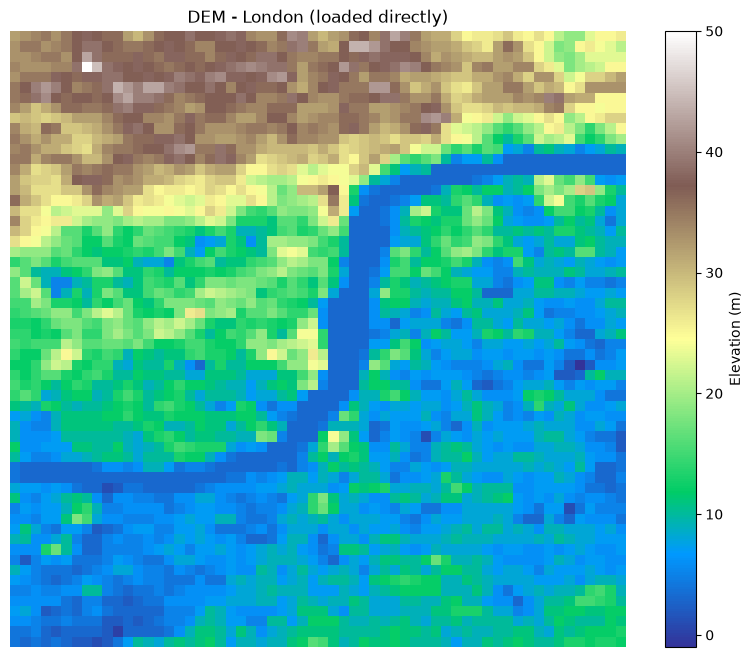

In [ ]:
import pathlib
import rasterio
import matplotlib.pyplot as plt

# The file path
file_path = pathlib.Path("lidar_data/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.zip")

# Check if it's actually a GeoTIFF
import os
print(f"File size: {os.path.getsize(file_path) / 1024:.2f} KB")

# Try to open it as a GeoTIFF directly
try:
    with rasterio.open(file_path) as src:
        dem = src.read(1)
        profile = src.profile
        
        print("✅ It's actually a GeoTIFF with .zip extension!")
        print(f"  Shape: {dem.shape}")
        print(f"  Elevation: {dem.min():.2f} - {dem.max():.2f} m")
        print(f"  CRS: {src.crs}")
        
        # Plot it
        plt.figure(figsize=(10, 8))
        plt.imshow(dem, cmap='terrain')
        plt.colorbar(label='Elevation (m)')
        plt.title('DEM - London (loaded directly)')
        plt.axis('off')
        plt.show()
        
except Exception as e:
    print(f"Not a GeoTIFF: {e}")
    
    # Try to read as raw file to see what it is
    with open(file_path, 'rb') as f:
        header = f.read(20)
        print(f"File header: {header[:20]}")

DEM loaded!
  Shape: (60, 60)
  Elevation: -1.00 - 50.00 m


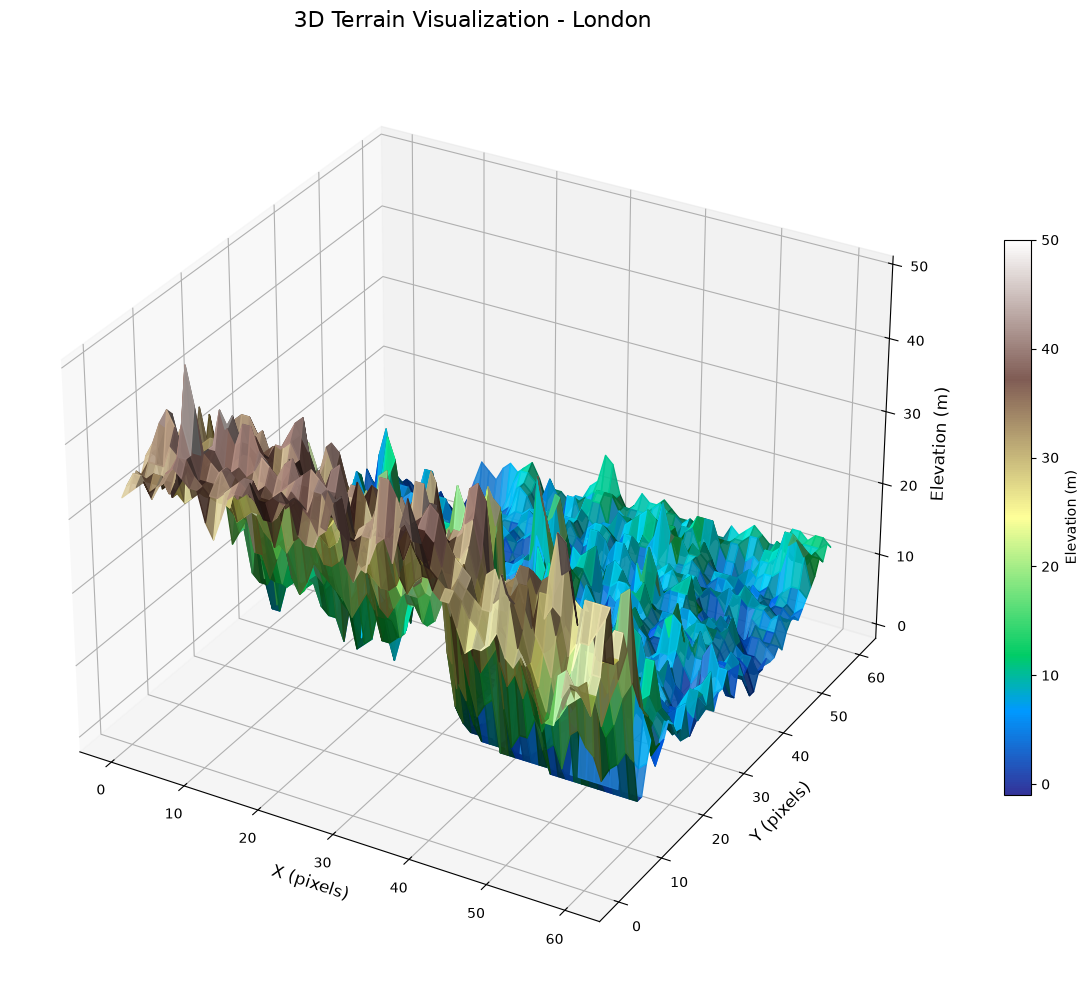


✅ 3D terrain saved: lidar_data/dem_3d_terrain.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource
import rasterio

# Load the DEM
file_path = "lidar_data/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.zip"

with rasterio.open(file_path) as src:
    dem = src.read(1).astype(np.float32)
    profile = src.profile
    bounds = src.bounds
    transform = src.transform

print(f"DEM loaded!")
print(f"  Shape: {dem.shape}")
print(f"  Elevation: {dem.min():.2f} - {dem.max():.2f} m")

# ============================================================
# 3D Visualization
# ============================================================

# Create mesh grid
x = np.linspace(0, dem.shape[1], dem.shape[1])
y = np.linspace(0, dem.shape[0], dem.shape[0])
X, Y = np.meshgrid(x, y)

# Set up figure
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Create hillshade for coloring
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(dem, cmap=plt.cm.terrain, vert_exag=3, blend_mode='soft')

# Plot surface
surf = ax.plot_surface(
    X, Y, dem, 
    facecolors=rgb,
    rstride=1, 
    cstride=1, 
    antialiased=True,
    alpha=0.9
)

# Labels and title
ax.set_title('3D Terrain Visualization - London', fontsize=16, pad=20)
ax.set_xlabel('X (pixels)', fontsize=12)
ax.set_ylabel('Y (pixels)', fontsize=12)
ax.set_zlabel('Elevation (m)', fontsize=12)

# Set viewing angle
ax.view_init(elev=30, azim=-60)

# Add colorbar
mappable = plt.cm.ScalarMappable(cmap=plt.cm.terrain)
mappable.set_array(dem)
plt.colorbar(mappable, ax=ax, shrink=0.6, label='Elevation (m)')

plt.tight_layout()
plt.savefig('lidar_data/dem_3d_terrain.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 3D terrain saved: lidar_data/dem_3d_terrain.png")

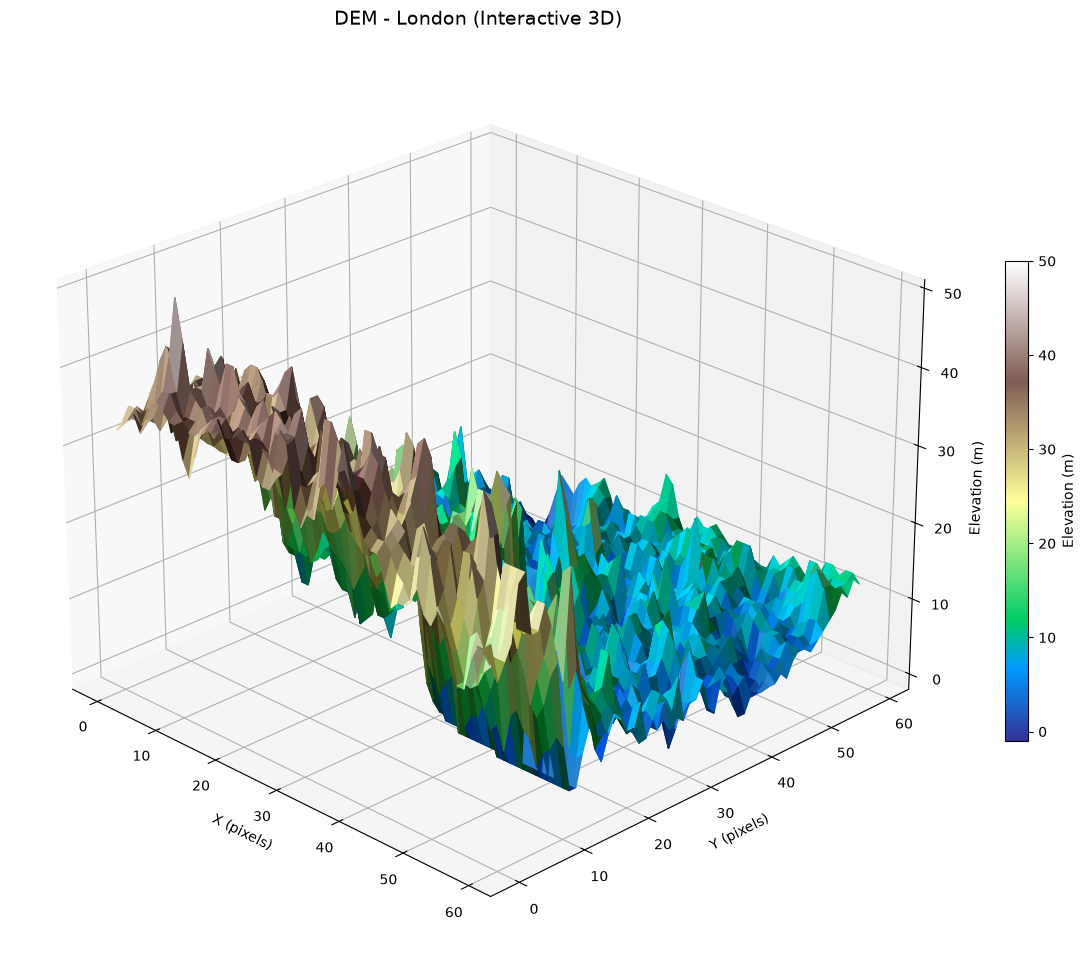

✅ Saved angle 1: elev=30°, azim=-60°
✅ Saved angle 2: elev=45°, azim=-45°
✅ Saved angle 3: elev=60°, azim=-30°
✅ Saved angle 4: elev=20°, azim=-90°
✅ Saved angle 5: elev=40°, azim=-135°


<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource
import rasterio

# Load DEM
with rasterio.open("lidar_data/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.zip") as src:
    dem = src.read(1).astype(np.float32)

# Downsample for speed (if needed)
step = max(1, max(dem.shape) // 100)
dem_small = dem[::step, ::step]

# Create mesh
x = np.arange(dem_small.shape[1])
y = np.arange(dem_small.shape[0])
X, Y = np.meshgrid(x, y)

# Create figure with interactive controls
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Colored surface
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(dem_small, cmap=plt.cm.terrain, vert_exag=3, blend_mode='soft')

surf = ax.plot_surface(X, Y, dem_small, facecolors=rgb, rstride=1, cstride=1, antialiased=True)

ax.set_title('DEM - London (Interactive 3D)', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Elevation (m)')

# Set initial view
ax.view_init(elev=25, azim=-45)

# Add colorbar
mappable = plt.cm.ScalarMappable(cmap=plt.cm.terrain)
mappable.set_array(dem_small)
plt.colorbar(mappable, ax=ax, shrink=0.5, label='Elevation (m)')

plt.tight_layout()
plt.show()

# Try different viewing angles
angles = [(30, -60), (45, -45), (60, -30), (20, -90), (40, -135)]
for i, (elev, azim) in enumerate(angles):
    ax.view_init(elev=elev, azim=azim)
    plt.savefig(f'lidar_data/dem_3d_angle_{i+1}.png', dpi=150, bbox_inches='tight')
    print(f"✅ Saved angle {i+1}: elev={elev}°, azim={azim}°")

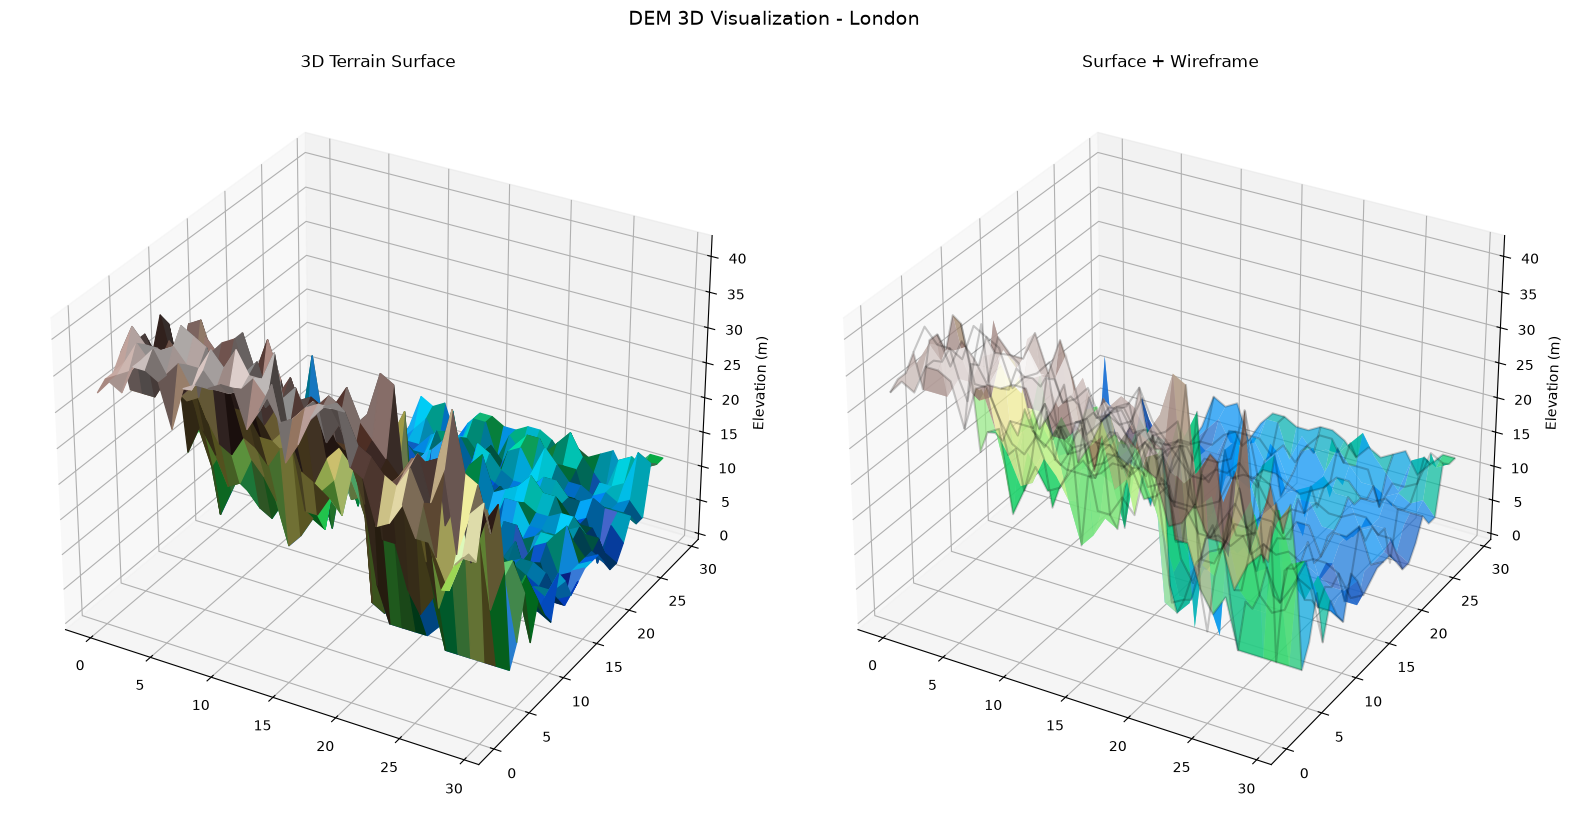

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource
import rasterio

with rasterio.open("lidar_data/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.zip") as src:
    dem = src.read(1).astype(np.float32)

# Downsample
step = 2
dem_small = dem[::step, ::step]
x = np.arange(dem_small.shape[1])
y = np.arange(dem_small.shape[0])
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(16, 8))

# Surface
ax1 = fig.add_subplot(121, projection='3d')
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(dem_small, cmap=plt.cm.terrain, vert_exag=3, blend_mode='soft')
ax1.plot_surface(X, Y, dem_small, facecolors=rgb, rstride=1, cstride=1, antialiased=True)
ax1.set_title('3D Terrain Surface', fontsize=12)
ax1.set_zlabel('Elevation (m)')
ax1.view_init(elev=30, azim=-60)

# Wireframe + Surface
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(X, Y, dem_small, cmap='terrain', alpha=0.7, rstride=2, cstride=2)
wire = ax2.plot_wireframe(X, Y, dem_small, color='black', alpha=0.2, rstride=3, cstride=3)
ax2.set_title('Surface + Wireframe', fontsize=12)
ax2.set_zlabel('Elevation (m)')
ax2.view_init(elev=30, azim=-60)

plt.suptitle('DEM 3D Visualization - London', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lidar_data/dem_3d_surface_wireframe.png', dpi=150, bbox_inches='tight')
plt.show()

DEM loaded: (60, 60)
Elevation: -1.0 - 50.0 m


⬇ 7 scenes  →  lidar_london  ██████████  7/7  [20:45]
⬇ 7 scenes  →  canopy_height  ██████████  7/7  [19:25]


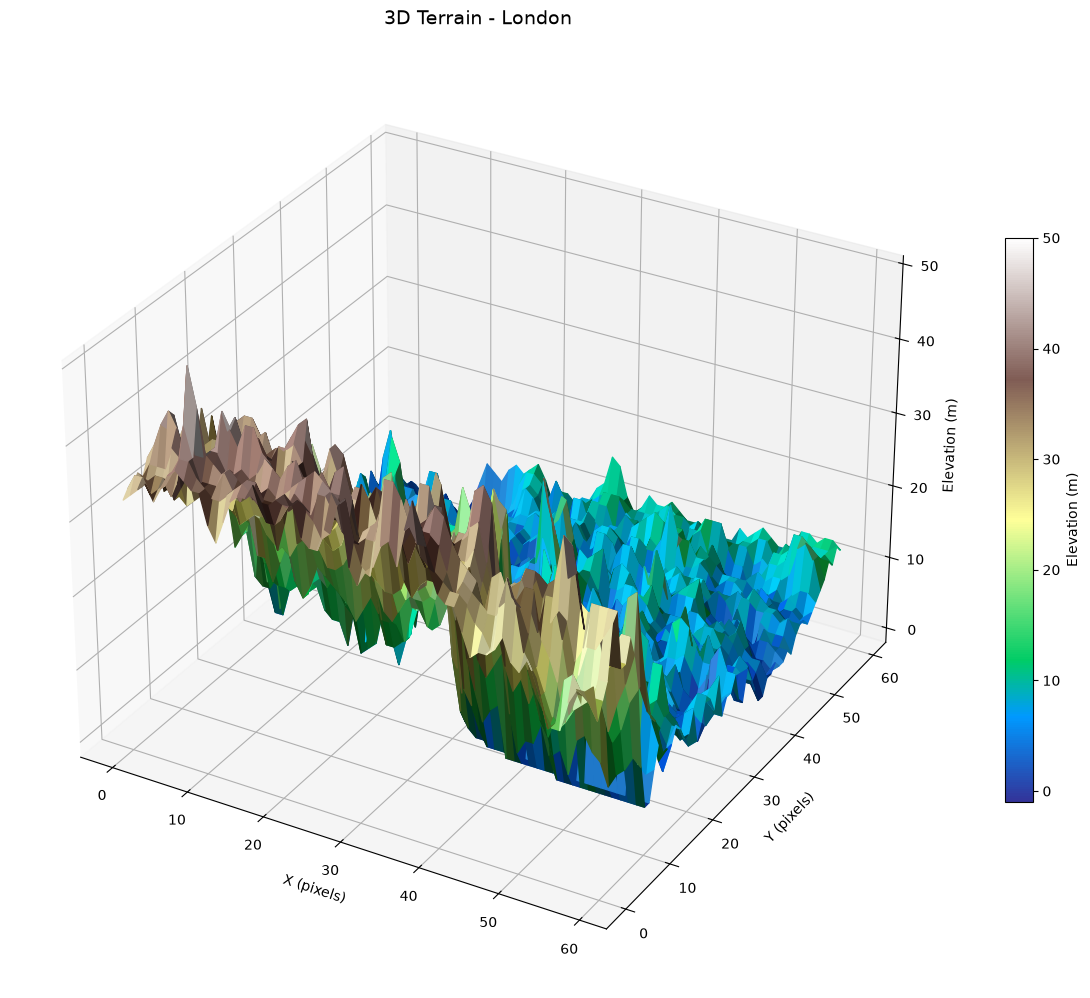

✅ 3D plot saved: lidar_data/dem_3d.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource
import rasterio

# Load DEM
file_path = "lidar_data/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.zip"

with rasterio.open(file_path) as src:
    dem = src.read(1).astype(np.float32)

print(f"DEM loaded: {dem.shape}")
print(f"Elevation: {dem.min():.1f} - {dem.max():.1f} m")

# ============================================================
# 3D Plot - This should work
# ============================================================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create grid
x = np.arange(dem.shape[1])
y = np.arange(dem.shape[0])
X, Y = np.meshgrid(x, y)

# Hillshade for coloring
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(dem, cmap=plt.cm.terrain, vert_exag=3, blend_mode='soft')

# Plot
surf = ax.plot_surface(X, Y, dem, facecolors=rgb, rstride=1, cstride=1, antialiased=True)

# Labels
ax.set_title('3D Terrain - London', fontsize=14, pad=20)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Elevation (m)')

# View angle
ax.view_init(elev=30, azim=-60)

# Colorbar
mappable = plt.cm.ScalarMappable(cmap=plt.cm.terrain)
mappable.set_array(dem)
plt.colorbar(mappable, ax=ax, shrink=0.6, label='Elevation (m)')

plt.tight_layout()
plt.savefig('lidar_data/dem_3d.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ 3D plot saved: lidar_data/dem_3d.png")

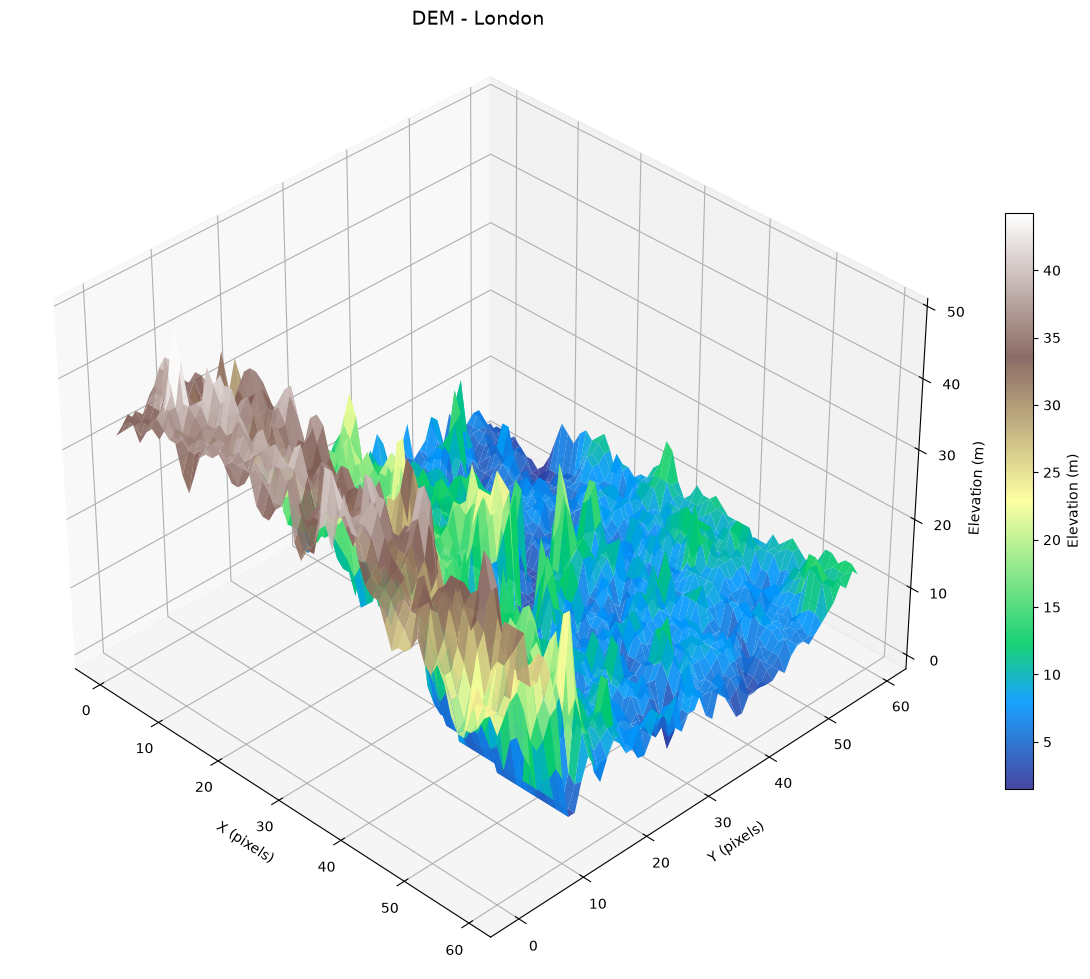

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import rasterio

# Load DEM
with rasterio.open("lidar_data/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.zip") as src:
    dem = src.read(1).astype(np.float32)

# Downsample if needed (60x60 is fine)
dem_small = dem

# Create grid
x = np.arange(dem_small.shape[1])
y = np.arange(dem_small.shape[0])
X, Y = np.meshgrid(x, y)

# Plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Surface plot with colormap
surf = ax.plot_surface(X, Y, dem_small, cmap='terrain', 
                       rstride=1, cstride=1, alpha=0.9, 
                       edgecolor='none', linewidth=0)

ax.set_title('DEM - London', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Elevation (m)')
ax.view_init(elev=35, azim=-45)

# Colorbar
plt.colorbar(surf, ax=ax, shrink=0.6, label='Elevation (m)')

plt.tight_layout()
plt.show()

In [ ]:
!pip install plotly nbformat ipython --quiet

In [ ]:
import numpy as np
import rasterio
import plotly.graph_objects as go

# Load DEM
with rasterio.open("lidar_data/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.zip") as src:
    dem = src.read(1).astype(np.float32)

print(f"DEM shape: {dem.shape}")
print(f"Elevation: {dem.min():.1f} - {dem.max():.1f} m")

# Create interactive 3D surface
fig = go.Figure(data=[go.Surface(
    z=dem,
    colorscale='Viridis',
    colorbar=dict(title='Elevation (m)'),
    hovertemplate='Elevation: %{z:.1f} m<extra></extra>'
)])

fig.update_layout(
    title='Interactive 3D DEM - London',
    scene=dict(
        xaxis_title='X (pixels)',
        yaxis_title='Y (pixels)',
        zaxis_title='Elevation (m)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.0)
        )
    ),
    width=900,
    height=700
)

# Show interactive plot
fig.show()

# Save as HTML for sharing
fig.write_html("lidar_data/dem_3d_interactive.html")
print("✅ Interactive HTML saved: lidar_data/dem_3d_interactive.html")

DEM shape: (60, 60)
Elevation: -1.0 - 50.0 m


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
import zipfile
import pathlib
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show

# Your ZIP file path
zip_path = "lidar_data/opentopography/opentopo_SRTMGL3_-0.15_51.47_dem.zip"
extract_dir = pathlib.Path("lidar_data/extracted")
extract_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Extract the ZIP
# ============================================================
print("📦 Extracting ZIP file...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    extracted_files = zip_ref.namelist()
    print(f"   Extracted {len(extracted_files)} files:")
    for f in extracted_files:
        print(f"     - {f}")

# Find the DEM file
dem_file = None
for f in extracted_files:
    if f.endswith('.tif') or f.endswith('.tiff'):
        dem_file = extract_dir / f
        break

if dem_file is None:
    # If no tif, try to find any file
    for f in extracted_files:
        if not f.endswith('/'):
            dem_file = extract_dir / f
            break

print(f"\n📁 DEM file: {dem_file}")

# ============================================================
# 2. Load and Visualize the DEM
# ============================================================
with rasterio.open(dem_file) as src:
    dem = src.read(1).astype(np.float32)
    profile = src.profile
    bounds = src.bounds
    transform = src.transform
    
    print(f"\n✅ DEM loaded!")
    print(f"   Shape: {dem.shape}")
    print(f"   Elevation: {dem.min():.2f} - {dem.max():.2f} m")
    print(f"   Mean: {dem.mean():.2f} m")
    print(f"   CRS: {src.crs}")

# ============================================================
# 3. Visualize
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# DEM
im1 = axes[0, 0].imshow(dem, cmap='terrain')
axes[0, 0].set_title('DEM - Elevation', fontsize=12)
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], label='Elevation (m)')

# Hillshade
from matplotlib.colors import LightSource
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem, vert_exag=2)
axes[0, 1].imshow(hillshade, cmap='gray')
axes[0, 1].set_title('Hillshade', fontsize=12)
axes[0, 1].axis('off')

# Slope
from rasterio.features import slope
slope_arr = slope(dem, transform)
im3 = axes[0, 2].imshow(slope_arr, cmap='YlOrRd', vmin=0, vmax=30)
axes[0, 2].set_title('Slope (degrees)', fontsize=12)
axes[0, 2].axis('off')
plt.colorbar(im3, ax=axes[0, 2], label='Degrees')

# Elevation histogram
axes[1, 0].hist(dem.flatten(), bins=30, color='green', alpha=0.7)
axes[1, 0].set_title('Elevation Distribution', fontsize=12)
axes[1, 0].set_xlabel('Elevation (m)')
axes[1, 0].set_ylabel('Count')

# Contour
from matplotlib.contour import ContourSet
contour = axes[1, 1].contour(dem, levels=10, cmap='viridis')
axes[1, 1].set_title('Contour Map', fontsize=12)
axes[1, 1].axis('off')

# 3D-like view
from scipy.ndimage import zoom
dem_small = zoom(dem, 0.3)
axes[1, 2].imshow(dem_small, cmap='terrain', extent=[0, dem.shape[1], dem.shape[0], 0])
axes[1, 2].set_title('Overview', fontsize=12)
axes[1, 2].axis('off')

plt.suptitle(f'DEM Analysis - {dem_file.name}', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('lidar_data/dem_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved: lidar_data/dem_visualization.png")

# ============================================================
# 4. Save processed DEM as GeoTIFF
# ============================================================
output_path = "lidar_data/dem_processed.tif"
with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=dem.shape[0],
    width=dem.shape[1],
    count=1,
    dtype=np.float32,
    crs=profile['crs'],
    transform=profile['transform'],
    compress='deflate',
    nodata=-9999
) as dst:
    dst.write(dem.astype(np.float32), 1)

print(f"✅ Processed DEM saved: {output_path}")

# ============================================================
# 5. Summary
# ============================================================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Source: {zip_path}")
print(f"Extracted: {dem_file}")
print(f"Shape: {dem.shape[0]} x {dem.shape[1]} pixels")
print(f"Area: {(bounds.right - bounds.left):.3f}° x {(bounds.top - bounds.bottom):.3f}°")
print(f"Elevation: {dem.min():.1f} - {dem.max():.1f} m")
print(f"Outputs: {output_path}, lidar_data/dem_visualization.png")

📦 Extracting ZIP file...


BadZipFile: File is not a zip file

In [ ]:
# ============================================================
# 8. Canopy Height Estimation using Satellite Imagery (DINOv3)
# ============================================================
print("\n" + "="*60)
print("CANOPY HEIGHT ESTIMATION WITH DINOv3")
print("="*60)

if scene_path:
    try:
        from pygeovision.models.foundation.dinov3 import DINOv3Adapter
        
        # Initialize DINOv3 for canopy height
        dinov3 = DINOv3Adapter()
        
        # Load satellite imagery
        import rasterio
        with rasterio.open(scene_path) as src:
            rgb = src.read([3, 2, 1])  # RGB bands
            
            # Normalize
            rgb_normalized = rgb / 10000.0
            rgb_normalized = np.clip(rgb_normalized, 0, 1)
            
            # Extract features
            print("Extracting DINOv3 features...")
            features = dinov3.extract_features(rgb_normalized)
            
            print(f"Feature shape: {features.shape}")
            print("Features extracted successfully for canopy height estimation")
            
    except ImportError:
        print("DINOv3 not installed. Install with: pip install pygeovision[foundation]")


In [ ]:
# ============================================================
# 9. Complete Summary
# ============================================================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

print(f"\nData directory: {DATA_DIR}")
print(f"Sentinel-2 scene: {scene_path}")
print(f"SCL mask: {scl_path}")
print(f"LiDAR point cloud: {lidar_path}")

# List all outputs
print("\nOutput files:")
for f in DATA_DIR.rglob('*'):
    if f.is_file():
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  {f.name} ({size_mb:.2f} MB)")

print("\n✅ Canopy height estimation workflow complete!")
print(f"📁 Results saved to: {DATA_DIR}")